In [3]:
# Python packages
import scanpy as sc
import anndata as ad
import SEACells
from SEACells.core import summarize_by_SEACell
import pickle
import pandas as pd
import os 
import numpy as np
from os.path import join
import seaborn as sns

In [68]:
adata = sc.read_h5ad("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/sim2_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid2.16666666666667_Batch1Sub2_summarised_seacell.h5ad")


In [56]:
adata_preprocessed = sc.read_h5ad("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/preprocessed/sim2_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid2.16666666666667_Batch1Sub2_preprocessed.h5ad")
adata_preprocessed.X = adata_preprocessed.layers["logcounts"]
sc.pp.highly_variable_genes(adata_preprocessed, n_top_genes=2000)

sc.tl.pca(adata_preprocessed, svd_solver='arpack')
sc.pp.neighbors(adata_preprocessed, n_neighbors=10, n_pcs=50)
sc.tl.umap(adata_preprocessed)

/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector

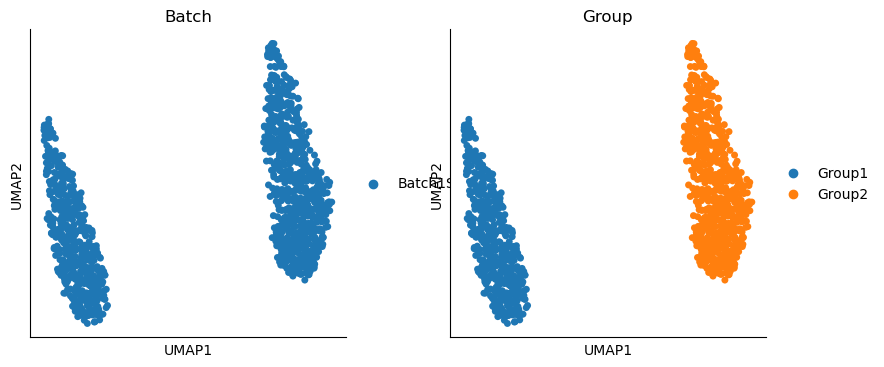

In [69]:
sc.pl.umap(adata_preprocessed, color=["Batch","Group"])

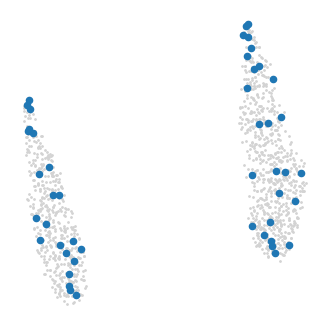

In [70]:
SEACells.plot.plot_initialization(adata_preprocessed, model)

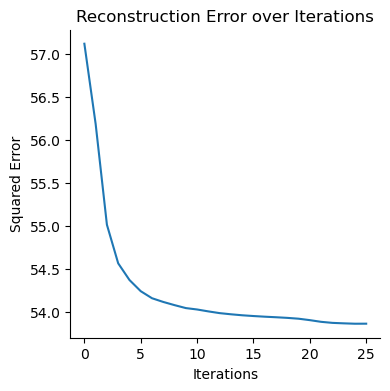

In [71]:
# Check for convergence 
model.plot_convergence()

In [72]:
adata_preprocessed

AnnData object with n_obs × n_vars = 1202 × 10000
    obs: 'Cell', 'Batch', 'Group', 'ExpLibSize', 'SubBatch', 'Sub', 'sum', 'detected', 'total', 'Discard', 'OldBatch', 'SEACell'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'BatchFacBatch1', 'BatchFacBatch2', 'BatchFacBatch3', 'BatchFacBatch4', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'mean', 'detected', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'Batch_colors', 'Group_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [ ]:
adata_preprocessed

/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


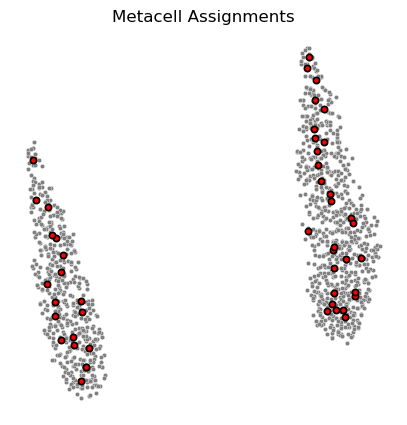

In [73]:
adata_preprocessed.obs["SEACell"] = model.get_hard_assignments()
SEACells.plot.plot_2D(adata_preprocessed, key='X_umap', colour_metacells=False)

In [53]:
n_cells_per_seacell = 20
n_SEACells = round(adata_preprocessed.n_obs/n_cells_per_seacell)
n_SEACells

60

Welcome to SEACells!
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/1202 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/1202 [00:00<?, ?it/s]

Building similarity LIL matrix...


...

Constructing CSR matrix...
Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 37 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 21/21 [00:00<00:00, 293.87it/s]

Selecting 11 cells from greedy initialization.
Randomly initialized A matrix.


Setting convergence threshold at 0.00057
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Converged after 25 iterations.


/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/seaborn/relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


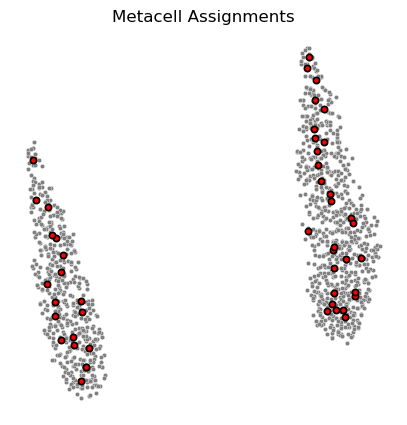

In [60]:
n_cells_per_seacell = 25
n_SEACells = round(adata_preprocessed.n_obs/n_cells_per_seacell)
build_kernel_on = 'X_pca' # key in ad.obsm to use for computing metacells
                          # This would be replaced by 'X_svd' for ATAC data

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

model = SEACells.core.SEACells(adata_preprocessed,
                  build_kernel_on=build_kernel_on,
                  n_SEACells=n_SEACells,
                  n_waypoint_eigs=n_waypoint_eigs,
                  convergence_epsilon = 1e-5)
model.construct_kernel_matrix()
model.initialize_archetypes()
model.fit(min_iter=10, max_iter=50)
# adata_preprocessed.obs["SEACell"] = model.get_hard_assignments()
SEACells.plot.plot_2D(adata_preprocessed, key='X_umap', colour_metacells=False)

In [64]:
def get_obs_data(h5ad_file_path):
    adata = ad.read_h5ad(h5ad_file_path, backed='r')
    obs_df = adata.obs.copy()
    adata.file.close()
    return obs_df

def get_model_data(model_path):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
        assignments = model["model"].get_hard_assignments()
    return assignments



def calc_celltype_purity(obs_df, assignments):
    obs_df = obs_df.copy()
    obs_df['SEACell'] = assignments
    
    def purity_func(group):
        # Get the counts of each Group in the SEACell
        counts = group['Group'].value_counts()
        # Identify the most common Group and its count
        most_common_group = counts.idxmax()
        most_common_count = counts.max()
        # Total number of cells in the SEACell
        total_count = counts.sum()
        # Calculate purity
        purity = most_common_count / total_count
        return pd.Series({'Group': most_common_group, 'celltype_purity': purity})
    
    # Apply the function to each SEACell group
    result = obs_df.groupby('SEACell').apply(purity_func)
    return result


In [62]:
adata_preprocessed.write_h5ad("test_n_cell_per_SEACell25.h5ad")
summarised = summarize_by_SEACell(adata_preprocessed, summarize_layer="raw")
summarised.write_h5ad("test_n_cell_per_SEACell25_summarised.h5ad")

100%|██████████| 48/48 [00:00<00:00, 179.36it/s]
/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [66]:
# example 
obs_df = get_obs_data("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/preprocessed/sim2_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid0.5_Batch1Sub2_preprocessed.h5ad")

celltype_purity = calc_celltype_purity(obs_df, model.get_hard_assignments())

seacell_adata = sc.read_h5ad("test_n_cell_per_SEACell25_summarised.h5ad")
print(celltype_purity.head())
print(seacell_adata.obs.head())
seacell_adata.obs = seacell_adata.obs.join(celltype_purity, how = "inner")
print(seacell_adata.obs.head())
print(f"number of cells before filtering: {seacell_adata.n_obs}")
seacell_adata = seacell_adata[seacell_adata.obs["celltype_purity"] > 0.95]
print(f"number of cells after filtering: {seacell_adata.n_obs}")
seacell_adata.write_h5ad("test_n_cell_per_SEACell25_summarised_clean.h5ad")


             Group  celltype_purity
SEACell                            
SEACell-0   Group2         1.000000
SEACell-1   Group2         1.000000
SEACell-10  Group2         1.000000
SEACell-11  Group2         1.000000
SEACell-12  Group2         0.904762
Empty DataFrame
Columns: []
Index: [SEACell-17, SEACell-42, SEACell-16, SEACell-4, SEACell-28]
             Group  celltype_purity
SEACell-17  Group1              1.0
SEACell-42  Group1              1.0
SEACell-16  Group1              1.0
SEACell-4   Group1              1.0
SEACell-28  Group1              1.0
number of cells before filtering: 48
number of cells after filtering: 47


/home/akollot/anaconda3/envs/seacells_pipe/lib/python3.11/site-packages/anndata/_core/anndata.py:1292: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


# Split the simulation data by "Batch"

In [44]:
samplesheet_orig = pd.read_json("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/samplesheet.json")
samplesheet_orig.head()

,seed,lib.loc,dropout.type,dropout.shape,dropout.mid,batchCells,batch.facLoc,batch.facScale,group.prob,de.prob,de.facLoc,de.facScale,sim,sample_name,file_path,sparsity
0,1,12,experiment,-5,0.5000,"[10000, 10000, 10000, 10000, 10000, 10000]","[0.1, 0.15, 0.12, 0.18, 0.15, 0.25]","[0.1, 0.08, 0.12, 0.1, 0.12, 0.18]","[0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.142...","[0.1, 0.12, 0.08, 0.2, 0.12, 0.1, 0.16]","[0.1, 0.08, 0.12, 0.18, 0.06, 0.2, 0.14]","[0.4, 0.30000000000000004, 0.45, 0.48, 0.42, 0...",sim1,sim1_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,48.37
1,1,12,experiment,-5,0.8333,"[10000, 10000, 10000, 10000, 10000, 10000]","[0.1, 0.15, 0.12, 0.18, 0.15, 0.25]","[0.1, 0.08, 0.12, 0.1, 0.12, 0.18]","[0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.142...","[0.1, 0.12, 0.08, 0.2, 0.12, 0.1, 0.16]","[0.1, 0.08, 0.12, 0.18, 0.06, 0.2, 0.14]","[0.4, 0.30000000000000004, 0.45, 0.48, 0.42, 0...",sim1,sim1_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,51.00
2,1,12,experiment,-5,1.1667,"[10000, 10000, 10000, 10000, 10000, 10000]","[0.1, 0.15, 0.12, 0.18, 0.15, 0.25]","[0.1, 0.08, 0.12, 0.1, 0.12, 0.18]","[0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.142...","[0.1, 0.12, 0.08, 0.2, 0.12, 0.1, 0.16]","[0.1, 0.08, 0.12, 0.18, 0.06, 0.2, 0.14]","[0.4, 0.30000000000000004, 0.45, 0.48, 0.42, 0...",sim1,sim1_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,54.62
3,1,12,experiment,-5,1.5000,"[10000, 10000, 10000, 10000, 10000, 10000]","[0.1, 0.15, 0.12, 0.18, 0.15, 0.25]","[0.1, 0.08, 0.12, 0.1, 0.12, 0.18]","[0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.142...","[0.1, 0.12, 0.08, 0.2, 0.12, 0.1, 0.16]","[0.1, 0.08, 0.12, 0.18, 0.06, 0.2, 0.14]","[0.4, 0.30000000000000004, 0.45, 0.48, 0.42, 0...",sim1,sim1_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,59.03
4,1,12,experiment,-5,1.8333,"[10000, 10000, 10000, 10000, 10000, 10000]","[0.1, 0.15, 0.12, 0.18, 0.15, 0.25]","[0.1, 0.08, 0.12, 0.1, 0.12, 0.18]","[0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.142...","[0.1, 0.12, 0.08, 0.2, 0.12, 0.1, 0.16]","[0.1, 0.08, 0.12, 0.18, 0.06, 0.2, 0.14]","[0.4, 0.30000000000000004, 0.45, 0.48, 0.42, 0...",sim1,sim1_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,64.25


In [45]:
samplesheet_orig.columns

Index(['seed', 'lib.loc', 'dropout.type', 'dropout.shape', 'dropout.mid',
       'batchCells', 'batch.facLoc', 'batch.facScale', 'group.prob', 'de.prob',
       'de.facLoc', 'de.facScale', 'sim', 'sample_name', 'file_path',
       'sparsity'],
      dtype='object')

## Filtering function from the SEACells pipeline
* apply to every batch, then concat ad write 

In [109]:

def filtering(adata,
              cells_min_genes=100,
              cells_min_counts=10,
            #   cells_max_counts=50000,
              genes_min_cells=3,
              genes_min_counts=10):
    """
    Filters cells and genes based on various criteria.

    Parameters
    ----------
    adata_path : str
        Path to the AnnData file.
    cells_min_genes : int, optional
        Minimum number of genes to keep a cell, by default 200.
    cells_min_counts : int, optional
        Minimum total counts to keep a cell, by default 10.
    cells_max_counts : int, optional
        Maximum total counts to keep a cell, by default 50000.
    genes_min_cells : int, optional
        Minimum number of cells a gene must be present in to be kept, by default 3.
    genes_min_counts : int, optional
        Minimum number of counts for a gene to be kept, by default 10.
    max_genes_by_counts : int, optional
        Maximum number of genes to keep based on counts, by default 2500.
    Returns
    -------
    AnnData
        Filtered AnnData object.
    """

    ######### Cell filtering #########
    sc.pp.filter_cells(adata, min_genes=cells_min_genes)
    sc.pp.filter_cells(adata, min_counts=cells_min_counts)
    # sc.pp.filter_cells(adata, max_counts=cells_max_counts)
    # adata = adata[adata.obs.pct_counts_mt < pct_counts_mt, :]
    # adata = adata[adata.obs.pct_counts_ribo> 5, :] # this is actually very bad if you have single-nuclei sequencing data!
    ######### Gene filtering #########
    sc.pp.filter_genes(adata, min_cells=genes_min_cells)
    sc.pp.filter_genes(adata, min_counts=genes_min_counts)

    return adata

In [118]:
original_sim1 =sc.read_h5ad("/local/Projects/AAkalin_Neuroblastoma/data/Luecken_Theis_NatMethods_2021_benchmarking/datasets/sim1_raw.h5ad")
original_sim1

AnnData object with n_obs × n_vars = 12097 × 9979
    obs: 'Cell', 'Batch', 'Group', 'ExpLibSize', 'sum', 'detected', 'percent_top_50', 'percent_top_100', 'percent_top_200', 'percent_top_500', 'total', 'Discard', 'size_factors', 'celltype', 'batch'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'BatchFacBatch1', 'BatchFacBatch2', 'BatchFacBatch3', 'BatchFacBatch4', 'BatchFacBatch5', 'BatchFacBatch6', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'DEFacGroup5', 'DEFacGroup6', 'DEFacGroup7', 'mean', 'detected', 'gene_name'
    layers: 'counts'

In [117]:
samplesheet_orig["file_path"][0]

'/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/sim1_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid0.5.h5ad'

In [116]:
test = sc.read_h5ad(samplesheet_orig["file_path"][0])
print(test)

AnnData object with n_obs × n_vars = 12075 × 9927
    obs: 'Cell', 'Batch', 'Group', 'ExpLibSize', 'sum', 'detected', 'total', 'Discard'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'BatchFacBatch1', 'BatchFacBatch2', 'BatchFacBatch3', 'BatchFacBatch4', 'BatchFacBatch5', 'BatchFacBatch6', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'DEFacGroup5', 'DEFacGroup6', 'DEFacGroup7', 'mean', 'detected'


AnnData object with n_obs × n_vars = 12075 × 9673
    obs: 'Cell', 'Batch', 'Group', 'ExpLibSize', 'sum', 'detected', 'total', 'Discard', 'n_genes', 'n_counts'
    var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'BatchFacBatch1', 'BatchFacBatch2', 'BatchFacBatch3', 'BatchFacBatch4', 'BatchFacBatch5', 'BatchFacBatch6', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'DEFacGroup5', 'DEFacGroup6', 'DEFacGroup7', 'mean', 'detected', 'n_cells', 'n_counts'

<function matplotlib.pyplot.show(close=None, block=None)>

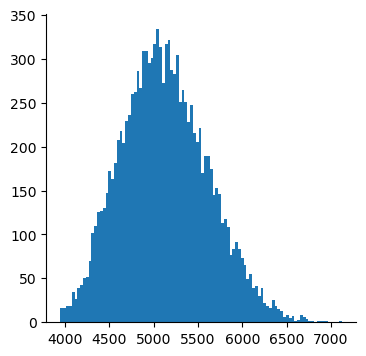

In [111]:
import matplotlib.pyplot as plt
plt.hist(test.obs.n_genes, bins=100)
plt.show



In [115]:
np.quantile(test.obs.n_counts, 0.90)

91156.0

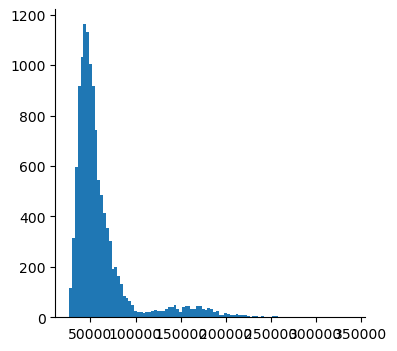

In [112]:
plt.hist(test.obs.n_counts, bins=100)
plt.show()

In [46]:
outdir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/split_batch"
# RUN ONLY ONCE
# for ind, row in samplesheet_orig.iterrows():
#     adata_path = row.file_path
#     adata = sc.read_h5ad(adata_path)
#     if row.sim == "sim1":
#         batch_key = "Batch"
#     elif row.sim == "sim2":
#         batch_key = "SubBatch"
#     for batch in adata.obs[batch_key].unique():
#         outfile = join(outdir, f"{row.sample_name}_{batch}.h5ad")
#         adata_batch = adata[adata.obs[batch_key] == batch].copy()
#         adata_batch.write_h5ad(outfile)
#         print(f"Saved {outfile}")
    

In [47]:
outdir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/split_batch"

def make_samplesheet(dir):
    files = os.listdir(dir)
    files = [file for file in files if file.endswith(".h5ad") or file.endswith(".h5") or file.endswith(".hdf5")]
    file_paths = [os.path.join(dir, file) for file in files] #[os.path.abspath(
    file_paths = [os.path.abspath(file) for file in file_paths]
    sample_name = [file.split(".h5ad")[0] for file in files]
    df = pd.DataFrame({"sample_name": sample_name, "file_path": file_paths})
    return df

samplesheet = make_samplesheet(outdir)
samplesheet["sim"] = samplesheet.apply(lambda x: "sim2" if "sim2" in x["file_path"] else "sim1", axis = 1)
samplesheet.to_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/split_batch/samplesheet.csv")
samplesheet_sim1 = samplesheet[samplesheet["sim"] == "sim1"]
samplesheet_sim2 = samplesheet[samplesheet["sim"] == "sim2"]

samplesheet_sim1.to_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/samplesheet_sim1.csv")
samplesheet_sim2.to_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/samplesheet_sim2.csv")

# Process Sim 2

In [48]:
samplesheet_sim2 = pd.read_csv("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/samplesheet_sim2.csv", index_col = 0).reset_index(drop = True)

samplesheet_sim2["Batch"] = samplesheet_sim2.file_path.apply(lambda x: x.split(".h5ad")[0])
samplesheet_sim2["Batch"] = samplesheet_sim2.Batch.apply(lambda x: x.split("_")[-1])
samplesheet_sim2["parent_sample"] = samplesheet_sim2.apply(
    lambda x: os.path.basename(x.file_path).split('_' + x.Batch)[0],
    axis=1
)

seacell_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell"
preprocessed_dir = "/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/preprocessed"
# add seacell file path to samplesheet for each sample_name
samplesheet_sim2["seacell_path"] = samplesheet_sim2.sample_name.apply(lambda x: join(seacell_dir, x + "_summarised_seacell.h5ad"))
samplesheet_sim2["model_path"] = samplesheet_sim2["seacell_path"].apply(lambda x: x.replace("summarised_seacell.h5ad", "model.pkl"))
samplesheet_sim2["preprocessed_path"] = samplesheet_sim2.sample_name.apply(lambda x: join(preprocessed_dir, x + "_preprocessed.h5ad"))
samplesheet_sim2.head()
samplesheet_orig = pd.read_json("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/samplesheet.json")
samplesheet_orig["parent_sample"] = samplesheet_orig["sample_name"]
del samplesheet_orig["sample_name"]
samplesheet_sim2 = samplesheet_sim2.merge(samplesheet_orig.loc[:, ~samplesheet_orig.columns.isin(["seed", "file_path"])], how = "left")


In [49]:
samplesheet_sim2.head()

,sample_name,file_path,sim,Batch,parent_sample,seacell_path,model_path,preprocessed_path,lib.loc,dropout.type,dropout.shape,dropout.mid,batchCells,batch.facLoc,batch.facScale,group.prob,de.prob,de.facLoc,de.facScale,sparsity
0,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,sim2,Batch1Sub1,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,12,experiment,-5,0.5,"[10000, 10000, 10000, 10000]","[0.2, 0.25, 0.22, 0.28]","[0.1, 0.08, 0.12, 0.1]","[0.25, 0.25, 0.25, 0.25]","[0.1, 0.12, 0.08, 0.2]","[0.1, 0.08, 0.12, 0.18]","[0.4, 0.30000000000000004, 0.45, 0.48]",37.67
1,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,sim2,Batch1Sub2,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,12,experiment,-5,0.5,"[10000, 10000, 10000, 10000]","[0.2, 0.25, 0.22, 0.28]","[0.1, 0.08, 0.12, 0.1]","[0.25, 0.25, 0.25, 0.25]","[0.1, 0.12, 0.08, 0.2]","[0.1, 0.08, 0.12, 0.18]","[0.4, 0.30000000000000004, 0.45, 0.48]",37.67
2,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,sim2,Batch1Sub3,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,12,experiment,-5,0.5,"[10000, 10000, 10000, 10000]","[0.2, 0.25, 0.22, 0.28]","[0.1, 0.08, 0.12, 0.1]","[0.25, 0.25, 0.25, 0.25]","[0.1, 0.12, 0.08, 0.2]","[0.1, 0.08, 0.12, 0.18]","[0.4, 0.30000000000000004, 0.45, 0.48]",37.67
3,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,sim2,Batch1Sub4,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,12,experiment,-5,0.5,"[10000, 10000, 10000, 10000]","[0.2, 0.25, 0.22, 0.28]","[0.1, 0.08, 0.12, 0.1]","[0.25, 0.25, 0.25, 0.25]","[0.1, 0.12, 0.08, 0.2]","[0.1, 0.08, 0.12, 0.18]","[0.4, 0.30000000000000004, 0.45, 0.48]",37.67
4,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,sim2,Batch2Sub1,sim2_DropoutSimulation_dropout.typeexperiment_...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,/local/Projects/AAkalin_Neuroblastoma/Results/...,12,experiment,-5,0.5,"[10000, 10000, 10000, 10000]","[0.2, 0.25, 0.22, 0.28]","[0.1, 0.08, 0.12, 0.1]","[0.25, 0.25, 0.25, 0.25]","[0.1, 0.12, 0.08, 0.2]","[0.1, 0.08, 0.12, 0.18]","[0.4, 0.30000000000000004, 0.45, 0.48]",37.67


In [50]:
def get_obs_data(h5ad_file_path):
    adata = ad.read_h5ad(h5ad_file_path, backed='r')
    obs_df = adata.obs.copy()
    adata.file.close()
    return obs_df

def get_model_data(model_path):
    with open(model_path, "rb") as f:
        model = pickle.load(f)
        assignments = model["model"].get_hard_assignments()
    return assignments



def calc_celltype_purity(obs_df, assignments):
    obs_df = obs_df.copy()
    obs_df['SEACell'] = assignments
    
    def purity_func(group):
        # Get the counts of each Group in the SEACell
        counts = group['Group'].value_counts()
        # Identify the most common Group and its count
        most_common_group = counts.idxmax()
        most_common_count = counts.max()
        # Total number of cells in the SEACell
        total_count = counts.sum()
        # Calculate purity
        purity = most_common_count / total_count
        return pd.Series({'Group': most_common_group, 'celltype_purity': purity})
    
    # Apply the function to each SEACell group
    result = obs_df.groupby('SEACell').apply(purity_func)
    return result


In [67]:
# example 
obs_df = get_obs_data("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/preprocessed/sim1_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid1.5_Batch6_preprocessed.h5ad")
assignments = get_model_data("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/sim1_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid1.5_Batch6_model.pkl")

celltype_purity = calc_celltype_purity(obs_df, assignments)

seacell_adata = sc.read_h5ad("/local/Projects/AAkalin_Neuroblastoma/Results/simulate_single_cell/h5ad/with_dropout/SEACells/seacell/sim1_DropoutSimulation_dropout.typeexperiment_dropout.shape5_dropout.mid1.5_Batch6_summarised_seacell.h5ad")
print(celltype_purity.head())
print(seacell_adata.obs.head())
seacell_adata.obs = seacell_adata.obs.join(celltype_purity, how = "inner")
print(seacell_adata.obs.head())
print(f"number of cells before filtering: {seacell_adata.n_obs}")
seacell_adata = seacell_adata[seacell_adata.obs["celltype_purity"] > 0.95]
print(f"number of cells after filtering: {seacell_adata.n_obs}")


             Group  celltype_purity
SEACell                            
SEACell-0   Group2              1.0
SEACell-1   Group3              1.0
SEACell-10  Group2              1.0
SEACell-11  Group1              1.0
SEACell-12  Group3              1.0
Empty DataFrame
Columns: []
Index: [SEACell-9, SEACell-14, SEACell-13, SEACell-11, SEACell-17]
             Group  celltype_purity
SEACell-9   Group1         0.520721
SEACell-14  Group1         1.000000
SEACell-13  Group1         1.000000
SEACell-11  Group1         1.000000
SEACell-17  Group1         1.000000
number of cells before filtering: 19
number of cells after filtering: 18
